<a href="https://colab.research.google.com/github/Renyambar/Reny_MachineLearning/blob/main/JS05/JS05_Tugas1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Klasifikasi Suara menggunakan kNN

## Langkah 1 - Import Library & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load data
# Pastikan file 'voice.csv' sudah diunggah
df = pd.read_csv('voice.csv')
display(df.head())

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male


## Langkah 2 - Preprocessing & Eksplorasi Fitur

In [2]:
# 2a. Encoding Label
le = LabelEncoder()
df['label'] = le.fit_transform(df['label']) # male = 1, female = 0

# 2b. Mencari Fitur Paling Optimal dengan Analisis Korelasi
plt.figure(figsize=(12,8))
corr_matrix = df.corr()
corr_target = abs(corr_matrix['label']).sort_values(ascending=False)
print("Korelasi Fitur terhadap Label:\n", corr_target)

# Berdasarkan korelasi tertinggi, kita pilih 5 fitur paling optimal
# meanfun, IQR, Q25, sp.ent, sd
fitur_pilihan = ['meanfun', 'IQR', 'Q25', 'sp.ent', 'sd']
X = df[fitur_pilihan]
y = df['label']

# 2c. Standarisasi Data (Wajib untuk kNN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Korelasi Fitur terhadap Label:
 label       1.000000
meanfun     0.833921
IQR         0.618916
Q25         0.511455
sp.ent      0.490552
sd          0.479539
sfm         0.357499
meanfreq    0.337415
centroid    0.337415
median      0.283919
maxdom      0.195657
mindom      0.194974
dfrange     0.192213
meandom     0.191067
mode        0.171775
maxfun      0.166461
minfun      0.136692
kurt        0.087195
Q75         0.066906
skew        0.036627
modindx     0.030801
Name: label, dtype: float64


<Figure size 1200x800 with 0 Axes>

## Langkah 3 - Split Data
Memisahkan data menjadi data latih (training) dan data uji (testing) dengan rasio 80:20.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print(f"Jumlah data latih: {X_train.shape[0]}")
print(f"Jumlah data uji: {X_test.shape[0]}")

Jumlah data latih: 2534
Jumlah data uji: 634


## Langkah 4 - Pembuatan Model kNN dan Pencarian $k$ Terbaik
Melakukan perulangan untuk mencari nilai $k$ yang menghasilkan akurasi terbaik pada data testing.

Nilai k terbaik adalah k = 9 dengan akurasi = 98.42%


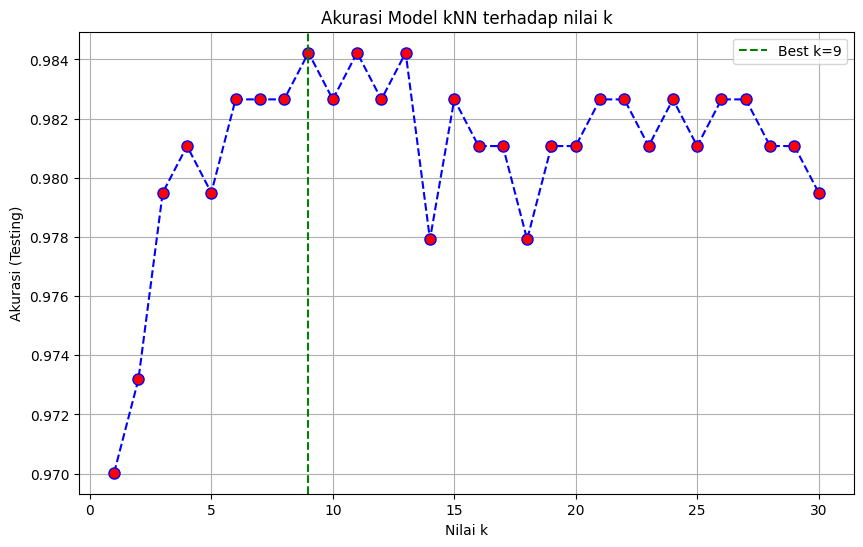

In [4]:
k_range = range(1, 31)
akurasi_list = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    akurasi = accuracy_score(y_test, y_pred)
    akurasi_list.append(akurasi)

# Menentukan k terbaik
best_k = k_range[np.argmax(akurasi_list)]
best_akurasi = max(akurasi_list)
print(f"Nilai k terbaik adalah k = {best_k} dengan akurasi = {best_akurasi*100:.2f}%")

# Visualisasi grafik analisis nilai k
plt.figure(figsize=(10,6))
plt.plot(k_range, akurasi_list, color='blue', linestyle='dashed', marker='o', markerfacecolor='red', markersize=8)
plt.title('Akurasi Model kNN terhadap nilai k')
plt.xlabel('Nilai k')
plt.ylabel('Akurasi (Testing)')
plt.axvline(x=best_k, color='green', linestyle='--', label=f'Best k={best_k}')
plt.legend()
plt.grid(True)
plt.show()

####Alasan Nilai $k$ Terbaik ($k = 9$)
1. Mencegah Overfitting: Pada nilai $k$ yang terlalu kecil (seperti $k=1$ atau $k=3$), kNN hanya melihat tetangga yang sangat berdekatan. Ini membuat model terlalu sensitif terhadap data pencilan/outlier, sehingga menghafal data training tetapi akurasinya menurun di data testing.
2. Mencegah Underfitting: Saat nilai $k$ diperbesar melampaui 15 atau 20, akurasi pada grafik mulai menurun kembali. Ini terjadi karena model mengambil keputusan dengan melihat terlalu banyak tetangga. Akibatnya, tetangga dari kelas suara pria yang sebenarnya sudah berada di jarak cukup jauh ikut mempengaruhi keputusan terhadap klasifikasi suara wanita.
3. Nilai $k=9$ memberikan keseimbangan paling pas. Pada titik ini model mempertimbangkan noise dengan baik tanpa terlalu menggeneralisasi tebakannya.

## Langkah 5 - Evaluasi Model
Menampilkan hasil evaluasi lebih detail untuk model dengan $k$ terbaik.

In [5]:
# Train model final dengan k terbaik
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train, y_train)
y_pred_best = knn_best.predict(X_test)

print("Laporan Klasifikasi:")
print(classification_report(y_test, y_pred_best))

Laporan Klasifikasi:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       297
           1       0.99      0.98      0.99       337

    accuracy                           0.98       634
   macro avg       0.98      0.98      0.98       634
weighted avg       0.98      0.98      0.98       634

